# IKEA India Sales & Operations Analytics

## Project Objective

The objective of this project is to prepare, clean, validate, and analyze IKEA sales and operations data to identify key business insights related to sales performance, customer behavior, product returns, supplier contribution, inventory risk, and delivery operations.

The cleaned datasets generated from this notebook will be used for PostgreSQL analysis and Power BI dashboard development.

## Tools & Libraries Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn


## Skills Demonstrated

- Data Cleaning
- Data Quality Validation
- Exploratory Data Analysis (EDA)
- Data Transformation
- Data Visualization
- Business Insight Generation
- Inventory Risk Analysis
- Return Analysis
- Customer Segmentation Analysis

## Dataset Overview

This project uses five datasets:

1. Customers
2. Orders
3. Products
4. Deliveries
5. Returns

The datasets represent an IKEA retail sales and operations environment covering customer transactions, product inventory, delivery performance, and product returns.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data

In [64]:
df_customers = pd.read_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\raw\customers.csv")
df_orders = pd.read_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\raw\orders.csv")
df_products = pd.read_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\raw\products.csv")
df_deliveries = pd.read_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\raw\deliveries.csv")
df_returns = pd.read_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\raw\returns.csv")

In [65]:
print("--- customers ---")
display(df_customers.head(2))

print("--- orders ---")
display(df_orders.head(2))

print("--- products ---")
display(df_products.head(2))

print("--- deliveries ---")
display(df_deliveries.head(2))

print("--- returns ---")
display(df_returns.head(2))

--- customers ---


,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Membership_Type,Join_Date
0,CUST0001,Tejus Gupta,Male,58,56+,Delhi,Delhi,Family,21-02-2023
1,CUST0002,Yash savaliya,Male,26,26-35,Delhi,Delhi,Regular,28-06-2023


--- orders ---


,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales_Amount,Discount,Payment_Method,Order_Status
0,ORD00001,27-06-2025,CUST0098,PROD002,4,24799.6,30,UPI,Cancelled
1,ORD00002,19-08-2024,CUST0356,PROD001,2,46510.1,5,Debit Card,Completed


--- products ---


,Product_ID,Product_Name,Category,Sub_Category,MRP,Cost,Supplier,Stock_On_Hand
0,PROD001,BRIMNES Mattresses,Bedroom,Mattresses,24479,18099.54,Supplier East,167
1,PROD002,EKET Cushions,Decor,Cushions,8857,4225.91,Supplier Local,366


--- deliveries ---


,Delivery_ID,Order_ID,Dispatch_Date,Delivery_Date,Carrier,Delivery_Status
0,DEL00001,ORD00001,2025-06-28,2025-07-03,Ecom Express,Delivered
1,DEL00002,ORD00002,2024-08-19,2024-08-22,Blue Dart,Delivered


--- returns ---


,Return_ID,Order_ID,Return_Date,Return_Reason,Refund_Amount
0,RET0001,ORD00008,2024-03-01,Damaged,18913.31
1,RET0002,ORD00042,2025-05-24,Damaged,109052.75


## Data Exploration and Sanity Checks

In [4]:
# Quick check for customers

print("--- Customers Data Health Check ---")
print(f"Shape (Rows, Columns) : {df_customers.shape}\n")

print("--- Structure & Data Types ---")
df_customers.info()

print("\n--- Missing Values Count ---")
display(df_customers.isnull().sum())

print(f"\n Total Duplicate Rows : {df_customers.duplicated().sum()}")

print("\n--- Summary Statistics ---")
display(df_customers.describe())

--- Customers Data Health Check ---
Shape (Rows, Columns) : (505, 9)

--- Structure & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      505 non-null    object
 1   Customer_Name    505 non-null    object
 2   Gender           505 non-null    object
 3   Age              505 non-null    int64 
 4   Age_Group        505 non-null    object
 5   City             500 non-null    object
 6   State            500 non-null    object
 7   Membership_Type  505 non-null    object
 8   Join_Date        505 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.6+ KB

--- Missing Values Count ---


Customer_ID        0
Customer_Name      0
Gender             0
Age                0
Age_Group          0
City               5
State              5
Membership_Type    0
Join_Date          0
dtype: int64


 Total Duplicate Rows : 5

--- Summary Statistics ---


,Age
count,505.000000
mean,41.439604
std,14.046155
min,18.000000
25%,29.000000
50%,41.000000
75%,53.000000
max,65.000000


In [5]:
# Quick check for orders

print("--- Orders Data Health Check ---")
print(f"Shape (Rows, Columns) : {df_orders.shape}\n")

print("--- Structure & Data Types")
df_orders.info()

print("\n--- Missing Values Count ---")
display(df_orders.isnull().sum())

print(f"\n Total Duplicate Values : {df_orders.duplicated().sum()}")

print("\n---Summary Satistics ---")
display(df_orders.describe())

--- Orders Data Health Check ---
Shape (Rows, Columns) : (5005, 9)

--- Structure & Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        5005 non-null   object 
 1   Order_Date      5005 non-null   object 
 2   Customer_ID     5005 non-null   object 
 3   Product_ID      5005 non-null   object 
 4   Quantity        5005 non-null   int64  
 5   Sales_Amount    5005 non-null   float64
 6   Discount        5005 non-null   int64  
 7   Payment_Method  5000 non-null   object 
 8   Order_Status    5005 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 352.0+ KB

--- Missing Values Count ---


Order_ID          0
Order_Date        0
Customer_ID       0
Product_ID        0
Quantity          0
Sales_Amount      0
Discount          0
Payment_Method    5
Order_Status      0
dtype: int64


 Total Duplicate Values : 5

---Summary Satistics ---


,Quantity,Sales_Amount,Discount
count,5005.000000,5005.000000,5005.000000
mean,1.928671,38017.646114,15.151848
std,1.169108,34705.775070,10.459894
min,1.000000,978.000000,0.000000
25%,1.000000,13988.800000,5.000000
50%,2.000000,27108.000000,15.000000
75%,2.000000,48455.700000,25.000000
max,5.000000,228535.000000,130.000000


In [6]:
# Quick check for products

print("--- Products Data Health Check ---")
print(f"Shape (Rows, Columns) : {df_products.shape}\n")

print("--- Structure & Data Types")
df_products.info()

print("\n--- Missing Values Count ---")
display(df_products.isnull().sum())

print(f"\n Total Duplicate Values : {df_products.duplicated().sum()}")

print("\n---Summary Satistics ---")
display(df_products.describe())

--- Products Data Health Check ---
Shape (Rows, Columns) : (100, 8)

--- Structure & Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     100 non-null    object 
 1   Product_Name   100 non-null    object 
 2   Category       100 non-null    object 
 3   Sub_Category   100 non-null    object 
 4   MRP            100 non-null    int64  
 5   Cost           100 non-null    float64
 6   Supplier       95 non-null     object 
 7   Stock_On_Hand  100 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 6.4+ KB

--- Missing Values Count ---


Product_ID       0
Product_Name     0
Category         0
Sub_Category     0
MRP              0
Cost             0
Supplier         5
Stock_On_Hand    0
dtype: int64


 Total Duplicate Values : 0

---Summary Satistics ---


,MRP,Cost,Stock_On_Hand
count,100.000000,100.000000,100.000000
mean,23237.780000,14085.186800,229.240000
std,13461.555541,8369.860057,199.781301
min,1304.000000,601.560000,-15.000000
25%,12024.500000,7185.932500,103.500000
50%,23241.500000,14070.640000,233.500000
75%,33690.000000,20607.522500,309.250000
max,48475.000000,34556.390000,1500.000000


In [7]:
# Quick check for deliveries

print("--- Deliveries Data Health Check ---")
print(f"Shape (Rows, Columns) : {df_deliveries.shape}\n")

print("--- Structure & Data Types")
df_deliveries.info()

print("\n--- Missing Values Count ---")
display(df_deliveries.isnull().sum())

print(f"\n Total Duplicate Values : {df_deliveries.duplicated().sum()}")

print("\n---Summary Satistics ---")
display(df_deliveries.describe())

--- Deliveries Data Health Check ---
Shape (Rows, Columns) : (5000, 6)

--- Structure & Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Delivery_ID      5000 non-null   object
 1   Order_ID         5000 non-null   object
 2   Dispatch_Date    5000 non-null   object
 3   Delivery_Date    4995 non-null   object
 4   Carrier          5000 non-null   object
 5   Delivery_Status  5000 non-null   object
dtypes: object(6)
memory usage: 234.5+ KB

--- Missing Values Count ---


Delivery_ID        0
Order_ID           0
Dispatch_Date      0
Delivery_Date      5
Carrier            0
Delivery_Status    0
dtype: int64


 Total Duplicate Values : 0

---Summary Satistics ---


,Delivery_ID,Order_ID,Dispatch_Date,Delivery_Date,Carrier,Delivery_Status
count,5000,5000,5000,4995,5000,5000
unique,5000,5000,732,738,15,2
top,DEL00001,ORD00001,2025-11-08,2025-07-08,Xpressbees,Delivered
freq,1,1,19,16,1042,4217


In [8]:
# Quick check for returns

print("--- Returns Data Health Check ---")
print(f"Shape (Rows, Columns) : {df_returns.shape}\n")

print("--- Structure & Data Types")
df_returns.info()

print("\n--- Missing Values Count ---")
display(df_returns.isnull().sum())

print(f"\n Total Duplicate Values : {df_returns.duplicated().sum()}")

print("\n---Summary Satistics ---")
display(df_returns.describe())

--- Returns Data Health Check ---
Shape (Rows, Columns) : (400, 5)

--- Structure & Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Return_ID      400 non-null    object 
 1   Order_ID       400 non-null    object 
 2   Return_Date    400 non-null    object 
 3   Return_Reason  395 non-null    object 
 4   Refund_Amount  400 non-null    float64
dtypes: float64(1), object(4)
memory usage: 15.8+ KB

--- Missing Values Count ---


Return_ID        0
Order_ID         0
Return_Date      0
Return_Reason    5
Refund_Amount    0
dtype: int64


 Total Duplicate Values : 0

---Summary Satistics ---


,Refund_Amount
count,400.000000
mean,28652.718600
std,28600.247554
min,1115.770000
25%,10471.840000
50%,20235.180000
75%,35032.687500
max,208611.580000


## Data Cleaning and Transformation

In [9]:
# Create explicit copies for the cleaning phase

df_customers_clean = df_customers.copy()
df_orders_clean = df_orders.copy()
df_products_clean = df_products.copy()
df_deliveries_clean = df_deliveries.copy()
df_returns_clean = df_returns.copy()

### 1. Cleaning Customers Data (df_customers_clean)

In [10]:
print(f"Shape before cleaning : {df_customers_clean.shape}")

Shape before cleaning : (505, 9)


In [11]:
# Handle Duplicates
df_customers_clean[df_customers_clean.duplicated(keep=False)]

,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Membership_Type,Join_Date
0,CUST0001,Tejus Gupta,Male,58,56+,Delhi,Delhi,Family,21-02-2023
25,CUST0026,Ishan Rao,Male,52,46-55,Bangalore,Karnataka,Business,20-09-2023
75,CUST0076,Divya Patel,Female,20,18-25,Hyderabad,Telangana,Premium,31-08-2025
150,CUST0151,Deepak Desai,Male,65,56+,Kolkata,West Bengal,Premium,19-02-2025
300,CUST0301,Miraj Shah,Male,56,56+,kolkata,West Bengal,Premium,08-08-2024
500,CUST0001,Tejus Gupta,Male,58,56+,Delhi,Delhi,Family,21-02-2023
501,CUST0026,Ishan Rao,Male,52,46-55,Bangalore,Karnataka,Business,20-09-2023
502,CUST0076,Divya Patel,Female,20,18-25,Hyderabad,Telangana,Premium,31-08-2025
503,CUST0151,Deepak Desai,Male,65,56+,Kolkata,West Bengal,Premium,19-02-2025
504,CUST0301,Miraj Shah,Male,56,56+,kolkata,West Bengal,Premium,08-08-2024


In [12]:
df_customers_clean.drop_duplicates(inplace=True)
df_customers_clean.duplicated().sum()

np.int64(0)

In [13]:
# Handle Missing values
df_customers_clean["City"] =  df_customers_clean["City"].fillna("Unknown")
df_customers_clean["State"] =  df_customers_clean["State"].fillna("Unknown")
df_customers_clean.isnull().sum()

Customer_ID        0
Customer_Name      0
Gender             0
Age                0
Age_Group          0
City               0
State              0
Membership_Type    0
Join_Date          0
dtype: int64

In [14]:
# Data Type Conversion
df_customers_clean["Join_Date"] = pd.to_datetime(df_customers_clean["Join_Date"], dayfirst=True)
df_customers_clean.dtypes

Customer_ID                object
Customer_Name              object
Gender                     object
Age                         int64
Age_Group                  object
City                       object
State                      object
Membership_Type            object
Join_Date          datetime64[ns]
dtype: object

In [15]:
# Fix Extra Spaces & Casing
string_columns = ["Customer_Name", "City", "State"]
for col in string_columns:
    df_customers_clean[col] = df_customers_clean[col].str.strip().str.title()
df_customers_clean.head()

,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Membership_Type,Join_Date
0,CUST0001,Tejus Gupta,Male,58,56+,Delhi,Delhi,Family,2023-02-21
1,CUST0002,Yash Savaliya,Male,26,26-35,Delhi,Delhi,Regular,2023-06-28
2,CUST0003,Harsh Sharma,Male,23,18-25,Hyderabad,Telangana,Family,2024-04-21
3,CUST0004,Sneha Vyas,Female,63,56+,Surat,Gujarat,Regular,2025-05-09
4,CUST0005,Arjun Das,Male,28,26-35,Chennai,Tamil Nadu,Business,2024-11-27


In [16]:
# Standardize Inconsist Cities
df_customers_clean["City"].unique()

array(['Delhi', 'Hyderabad', 'Surat', 'Chennai', 'Mumbai', 'Kolkata',
       'Jaipur', 'Pune', 'Unknown', 'Bangalore', 'Bengaluru', 'Ahmedabad',
       'Ahemdabad', 'New Delhi'], dtype=object)

In [17]:
city_mapping = {"Ahemdabad" : "Ahmedabad", "Bengaluru" : "Bangalore", "New Delhi" : "Delhi"}
df_customers_clean["City"] = df_customers_clean["City"].replace(city_mapping)
df_customers_clean["City"].unique()

array(['Delhi', 'Hyderabad', 'Surat', 'Chennai', 'Mumbai', 'Kolkata',
       'Jaipur', 'Pune', 'Unknown', 'Bangalore', 'Ahmedabad'],
      dtype=object)

In [18]:
print(f"Shape after cleaning : {df_customers_clean.shape}")

Shape after cleaning : (500, 9)


### 2. Cleaning Orders Data (df_orders_clean)

In [19]:
print(f"Shape before cleaning : {df_orders_clean.shape}")

Shape before cleaning : (5005, 9)


In [20]:
# Handle Duplicates
df_orders_clean[df_orders_clean.duplicated(keep=False)]

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales_Amount,Discount,Payment_Method,Order_Status
2,ORD00003,25-08-2025,CUST0157,PROD017,1,32104.8,20,Credit Card,Completed
302,ORD00303,03-11-2025,CUST0071,PROD029,1,18523.2,15,UPI,Returned
1100,ORD01101,13-05-2024,CUST0323,PROD075,1,11715.0,0,Cash on Delivery,Completed
2500,ORD02501,29-09-2024,CUST0488,PROD041,1,5680.0,20,Credit Card,Cancelled
4200,ORD04201,25-07-2025,CUST0300,PROD038,5,162110.0,0,UPI,Returned
5000,ORD00003,25-08-2025,CUST0157,PROD017,1,32104.8,20,Credit Card,Completed
5001,ORD00303,03-11-2025,CUST0071,PROD029,1,18523.2,15,UPI,Returned
5002,ORD01101,13-05-2024,CUST0323,PROD075,1,11715.0,0,Cash on Delivery,Completed
5003,ORD02501,29-09-2024,CUST0488,PROD041,1,5680.0,20,Credit Card,Cancelled
5004,ORD04201,25-07-2025,CUST0300,PROD038,5,162110.0,0,UPI,Returned


In [21]:
df_orders_clean.drop_duplicates(inplace=True)
df_orders_clean.duplicated().sum()

np.int64(0)

In [22]:
# Handle Missing values
df_orders_clean["Payment_Method"] = df_orders_clean["Payment_Method"].fillna("Not Specified")
df_orders_clean.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product_ID        0
Quantity          0
Sales_Amount      0
Discount          0
Payment_Method    0
Order_Status      0
dtype: int64

In [23]:
# Data Type Conversion
df_orders_clean["Order_Date"] = pd.to_datetime(df_orders_clean["Order_Date"], dayfirst=True)
df_orders_clean.dtypes

Order_ID                  object
Order_Date        datetime64[ns]
Customer_ID               object
Product_ID                object
Quantity                   int64
Sales_Amount             float64
Discount                   int64
Payment_Method            object
Order_Status              object
dtype: object

In [24]:
# Business Rule validation
df_orders_clean[df_orders_clean["Discount"] > 100]

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales_Amount,Discount,Payment_Method,Order_Status
50,ORD00051,2025-12-09,CUST0297,PROD066,3,55207.35,120,Credit Card,Returned
700,ORD00701,2025-06-09,CUST0175,PROD081,1,45379.00,130,Net Banking,Cancelled
2700,ORD02701,2024-02-24,CUST0105,PROD019,2,68350.60,110,Cash on Delivery,Completed
3700,ORD03701,2024-06-09,CUST0444,PROD098,1,10240.80,125,Credit Card,Completed


In [25]:
median_discount = df_orders_clean["Discount"].median()
df_orders_clean.loc[df_orders_clean["Discount"] > 100, "Discount"] = median_discount
(df_orders_clean["Discount"] > 100).sum()

np.int64(0)

In [26]:
print("--- check the Highest Value Orders ---")
display(df_orders_clean.sort_values(by="Sales_Amount", ascending=False).head(3))

--- check the Highest Value Orders ---


,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales_Amount,Discount,Payment_Method,Order_Status
2050,ORD02051,2024-11-26,CUST0159,PROD078,5,228535.0,0,Cash on Delivery,Returned
1182,ORD01183,2024-01-16,CUST0074,PROD081,5,226895.0,0,Debit Card,Completed
1502,ORD01503,2025-07-28,CUST0087,PROD081,5,226895.0,0,Credit Card,Completed


In [27]:
print(f"Shape after cleaning : {df_orders_clean.shape}")

Shape after cleaning : (5000, 9)


### 3. Cleaning Products Data (df_products_clean)

In [28]:
print(f"Shape before cleaning : {df_products_clean.shape}")

Shape before cleaning : (100, 8)


In [29]:
# Handle Missing values
df_products_clean.head()

,Product_ID,Product_Name,Category,Sub_Category,MRP,Cost,Supplier,Stock_On_Hand
0,PROD001,BRIMNES Mattresses,Bedroom,Mattresses,24479,18099.54,Supplier East,167
1,PROD002,EKET Cushions,Decor,Cushions,8857,4225.91,Supplier Local,366
2,PROD003,INGOLF Kids Beds,Kids Furniture,Kids Beds,15090,10574.73,Supplier South,56
3,PROD004,EKET Dining Chairs,Dining,Dining Chairs,26967,16289.09,NaN,99
4,PROD005,LINNMON TV Units,Living Room,TV Units,30634,18894.63,Supplier South,58


In [30]:
df_products_clean["Supplier"] = df_products_clean["Supplier"].fillna("Unknown")
df_products_clean.isnull().sum()

Product_ID       0
Product_Name     0
Category         0
Sub_Category     0
MRP              0
Cost             0
Supplier         0
Stock_On_Hand    0
dtype: int64

In [31]:
# Fix Extra Space & Standardize Inconsist Product Name
unique_products = sorted(df_products_clean["Product_Name"].unique())

for index, product in enumerate(unique_products):
    print(f"{product[:28]:<30}", end="")

    if (index + 1) % 3 == 0:
        print()

 VIMLE Kids Beds              ALEX Ceiling Lights           ALEX Cookware                 
ALEX Office Chairs            BILLY Kids Beds               BILLY Shelving Units          
BRIMNES Cushions              BRIMNES Floor Lamps           BRIMNES Mattresses            
BRIMNES Office Desks          BRIMNES Rugs                  EKET Beds                     
EKET Cushions                 EKET Dining Chairs            EKET Kids Beds                
FRIHETEN Bookcases            FRIHETEN Office Chairs        FRIHETEN Wall Art             
HEMNES Cabinets               HEMNES Floor Lamps            HEMNES Kids Chairs            
HEMNES Office Desks           HEMNES Outdoor Tables         HEMNES Shelving Units         
HEMNES Wall Art               HEMNES Wardrobes              Hemnes Cabinets               
INGOLF Bookcases              INGOLF Boxes                  INGOLF Floor Lamps            
INGOLF Kids Beds              KALLAX Boxes                  KALLAX Cabinets               

In [32]:
df_products_clean["Product_Name"] = df_products_clean["Product_Name"].str.strip()

def format_ikea_name(name):
    words = name.split()
    if len(words) == 0:
        return name
        
    brand = words[0].upper()
    description = [word.capitalize() for word in words[1:]]
    return " ".join([brand] + description)

df_products_clean["Product_Name"] = df_products_clean["Product_Name"].apply(format_ikea_name) 

unique_products = sorted(df_products_clean["Product_Name"].unique())
print(f"--- Total Unique Products: {len(unique_products)} ---\n")

for index, product in enumerate(unique_products):
    print(f"{product[:28]:<30}", end="")

    if (index + 1) % 3 == 0:
        print()

--- Total Unique Products: 96 ---

ALEX Ceiling Lights           ALEX Cookware                 ALEX Office Chairs            
BILLY Dining Chairs           BILLY Kids Beds               BILLY Shelving Units          
BRIMNES Cushions              BRIMNES Floor Lamps           BRIMNES Mattresses            
BRIMNES Office Desks          BRIMNES Rugs                  EKET Beds                     
EKET Cushions                 EKET Dining Chairs            EKET Kids Beds                
FRIHETEN Bookcases            FRIHETEN Office Chairs        FRIHETEN Wall Art             
HEMNES Cabinets               HEMNES Floor Lamps            HEMNES Kids Chairs            
HEMNES Office Desks           HEMNES Outdoor Tables         HEMNES Shelving Units         
HEMNES Wall Art               HEMNES Wardrobes              INGOLF Bookcases              
INGOLF Boxes                  INGOLF Floor Lamps            INGOLF Kids Beds              
KALLAX Boxes                  KALLAX Cabinets          

In [33]:
# Fix Outlier
print("--- Check Negative Stock ---")
display(df_products_clean.loc[df_products_clean["Stock_On_Hand"] < 0])
print("--- Check High Stock ---")
display(df_products_clean.loc[df_products_clean["Stock_On_Hand"] > 1000])

--- Check Negative Stock ---


,Product_ID,Product_Name,Category,Sub_Category,MRP,Cost,Supplier,Stock_On_Hand
9,PROD010,MALM Kids Chairs,Kids Furniture,Kids Chairs,48475,27558.02,Supplier East,-8
44,PROD045,LACK Ceiling Lights,Lighting,Ceiling Lights,37021,25987.13,Supplier North,-15
72,PROD073,RANARP Ceiling Lights,Lighting,Ceiling Lights,9117,5965.73,Supplier West,-5


--- Check High Stock ---


,Product_ID,Product_Name,Category,Sub_Category,MRP,Cost,Supplier,Stock_On_Hand
15,PROD016,VIMLE Cushions,Decor,Cushions,38069,22868.73,Supplier West,1200
66,PROD067,INGOLF Bookcases,Office Furniture,Bookcases,30038,20492.20,Supplier West,1500


In [34]:
# Fix Negative Stock
df_products_clean.loc[df_products_clean["Stock_On_Hand"] < 0, "Stock_On_Hand"] = 0

print("--- Final Verified Product Summary Statistics ---")
display(df_products_clean.describe())


--- Final Verified Product Summary Statistics ---


,MRP,Cost,Stock_On_Hand
count,100.000000,100.000000,100.000000
mean,23237.780000,14085.186800,229.520000
std,13461.555541,8369.860057,199.448354
min,1304.000000,601.560000,0.000000
25%,12024.500000,7185.932500,103.500000
50%,23241.500000,14070.640000,233.500000
75%,33690.000000,20607.522500,309.250000
max,48475.000000,34556.390000,1500.000000


In [35]:
print(f"Shape after cleaning : {df_products_clean.shape}")

Shape after cleaning : (100, 8)


### 4. Cleaning Deliveries Data (df_deliveries_clean)

In [36]:
print(f"Shape before cleaning : {df_deliveries_clean.shape}")

Shape before cleaning : (5000, 6)


In [37]:
df_deliveries_clean.head(10)

,Delivery_ID,Order_ID,Dispatch_Date,Delivery_Date,Carrier,Delivery_Status
0,DEL00001,ORD00001,2025-06-28,2025-07-03,Ecom Express,Delivered
1,DEL00002,ORD00002,2024-08-19,2024-08-22,Blue Dart,Delivered
2,DEL00003,ORD00003,2025-08-26,2025-08-29,Ecom Express,Delivered
3,DEL00004,ORD00004,2025-04-11,2025-04-19,Xpressbees,Delayed
4,DEL00005,ORD00005,2024-05-17,2024-05-20,Ecom Express,Delivered
5,DEL00006,ORD00006,2025-02-19,2025-02-23,Blue Dart,Delivered
6,DEL00007,ORD00007,2024-01-25,2024-01-29,Ecom Express,Delivered
7,DEL00008,ORD00008,2024-02-10,2024-02-13,BlueDart,Delivered
8,DEL00009,ORD00009,2024-02-19,2024-02-22,Blue Dart,Delivered
9,DEL00010,ORD00010,2025-03-03,2025-03-06,Delhivery,Delivered


In [38]:
# Data Type Conversion
df_deliveries_clean["Dispatch_Date"] = pd.to_datetime(df_deliveries_clean["Dispatch_Date"])
df_deliveries_clean["Delivery_Date"] = pd.to_datetime(df_deliveries_clean["Delivery_Date"])
df_deliveries_clean.dtypes

Delivery_ID                object
Order_ID                   object
Dispatch_Date      datetime64[ns]
Delivery_Date      datetime64[ns]
Carrier                    object
Delivery_Status            object
dtype: object

In [39]:
# Fix Inconsist Carrier Values 
df_deliveries_clean["Carrier"].unique()

array(['Ecom Express', 'Blue Dart', 'Xpressbees', 'BlueDart', 'Delhivery',
       'DTDC', 'blue dart', 'delhivery', 'EcomExpress', 'xpressbees',
       'DTDC ', ' dtdc', 'Blue Dart ', 'DELHIVERY', 'Ecom express'],
      dtype=object)

In [40]:
df_deliveries_clean["Carrier"] = df_deliveries_clean["Carrier"].str.strip().str.title()

carrier_mapping = {"Ecomexpress" : "Ecom Express", "Bluedart" : "Blue Dart", "Dtdc" : "DTDC", "Xpressbees" : "XpressBees"}
df_deliveries_clean["Carrier"] = df_deliveries_clean["Carrier"].replace(carrier_mapping)
df_deliveries_clean["Carrier"].unique()

array(['Ecom Express', 'Blue Dart', 'XpressBees', 'Delhivery', 'DTDC'],
      dtype=object)

In [41]:
# Fix Missing Value
missing_dates = df_deliveries_clean[df_deliveries_clean['Delivery_Date'].isnull()]
display(missing_dates[['Delivery_ID', 'Dispatch_Date', 'Delivery_Date', 'Carrier', 'Delivery_Status']])

,Delivery_ID,Dispatch_Date,Delivery_Date,Carrier,Delivery_Status
20,DEL00021,2024-02-16,NaT,DTDC,Delivered
500,DEL00501,2024-06-01,NaT,DTDC,Delivered
1200,DEL01201,2025-04-08,NaT,DTDC,Delivered
2400,DEL02401,2025-11-04,NaT,DTDC,Delivered
3600,DEL03601,2025-08-06,NaT,Delhivery,Delivered


In [42]:
df_deliveries_clean["Duration_Days"] = (df_deliveries_clean["Delivery_Date"] - df_deliveries_clean["Dispatch_Date"]).dt.days

carrier_median = df_deliveries_clean.groupby(["Carrier"])["Duration_Days"].median()
print("--- Delivery Days by Carrier(median) ---")
print(carrier_median)

--- Delivery Days by Carrier(median) ---
Carrier
Blue Dart       4.0
DTDC            4.0
Delhivery       4.0
Ecom Express    4.0
XpressBees      4.0
Name: Duration_Days, dtype: float64


In [43]:
missing_mask = df_deliveries_clean['Delivery_Date'].isnull()

df_deliveries_clean.loc[missing_mask, 'Delivery_Date'] = df_deliveries_clean.loc[missing_mask, 'Dispatch_Date'] + pd.to_timedelta(4, unit='D')

if 'Duration_Days' in df_deliveries_clean.columns:
    df_deliveries_clean = df_deliveries_clean.drop(columns=['Duration_Days'])

print("--- Final Deliveries Missing Value Check ---")
df_deliveries_clean.isnull().sum()

--- Final Deliveries Missing Value Check ---


Delivery_ID        0
Order_ID           0
Dispatch_Date      0
Delivery_Date      0
Carrier            0
Delivery_Status    0
dtype: int64

In [44]:
print(f"Shape after cleaning : {df_deliveries_clean.shape}")

Shape after cleaning : (5000, 6)


### 5. Cleaning Returns Data (df_returns_clean)

In [45]:
print(f"Shape before cleaning : {df_returns_clean.shape}")

Shape before claning : (400, 5)


In [46]:
df_returns_clean.head(10)

,Return_ID,Order_ID,Return_Date,Return_Reason,Refund_Amount
0,RET0001,ORD00008,2024-03-01,Damaged,18913.31
1,RET0002,ORD00042,2025-05-24,Damaged,109052.75
2,RET0003,ORD00051,2025-12-20,Changed Mind,35104.08
3,RET0004,ORD00057,2025-01-06,Damaged,30080.22
4,RET0005,ORD00058,2025-06-19,Damaged,151497.01
5,RET0006,ORD00081,2024-02-08,Late Delivery,42901.57
6,RET0007,ORD00086,2025-04-08,Damaged,44290.31
7,RET0008,ORD00107,2025-05-12,Quality Issue,36889.74
8,RET0009,ORD00109,2025-07-24,NaN,20135.93
9,RET0010,ORD00115,2025-09-27,Damaged,6727.96


In [47]:
# Data Type Conversion
df_returns_clean["Return_Date"] = pd.to_datetime(df_returns_clean["Return_Date"])
df_returns_clean.dtypes

Return_ID                object
Order_ID                 object
Return_Date      datetime64[ns]
Return_Reason            object
Refund_Amount           float64
dtype: object

In [48]:
# Fix Missing Values in Return_Reason
missing_reasons = df_returns_clean[df_returns_clean['Return_Reason'].isnull()]
display(missing_reasons)

,Return_ID,Order_ID,Return_Date,Return_Reason,Refund_Amount
8,RET0009,ORD00109,2025-07-24,NaN,20135.93
66,RET0067,ORD00694,2024-09-28,NaN,37394.72
125,RET0126,ORD01232,2024-06-13,NaN,9186.99
260,RET0261,ORD02576,2025-02-09,NaN,13806.36
335,RET0336,ORD03440,2024-04-02,NaN,37515.78


In [49]:
df_returns_clean["Return_Reason"] = df_returns_clean["Return_Reason"].fillna("Not Specified")
print("--- Final Missing Values Check ---")
df_returns_clean.isnull().sum()

--- Final Missing Values Check ---


Return_ID        0
Order_ID         0
Return_Date      0
Return_Reason    0
Refund_Amount    0
dtype: int64

In [50]:
print("--- check the Highest Value Returns ---")
display(df_returns_clean.sort_values(by='Refund_Amount', ascending=False).head(3))

--- check the Highest Value Returns ---


,Return_ID,Order_ID,Return_Date,Return_Reason,Refund_Amount
210,RET0211,ORD02051,2024-12-09,Late Delivery,208611.58
21,RET0022,ORD00228,2024-02-28,Quality Issue,179045.57
268,RET0269,ORD02699,2024-10-11,Quality Issue,153171.37


In [51]:
print(f"Shape after cleaning : {df_returns_clean.shape}")

Shape after cleaning : (400, 5)


## Clean Data Validation

### Customers Data
- Removed duplicate customer records.
- Filled missing values in City and State with "Unknown".
- Converted Join_Date to datetime format.
- Standardized text formatting and corrected city name inconsistencies.
  
### Orders Data
- Converted Order_Date to datetime format.
- Removed 5 duplicate order records.
- Validated high-value sales transactions and confirmed they were legitimate.
  
### Products Data
- Corrected negative inventory values in Stock_On_Hand.
- Replaced invalid stock quantities with 0.
- Verified inventory consistency after correction.
  
### Deliveries Data
- Converted date columns to datetime format.
- Standardized courier partner names.
- Imputed missing delivery dates using carrier median delivery duration.
- Verified delivery timeline consistency.
  
### Returns Data
- Converted Return_Date to datetime format.
- Filled missing Return_Reason values with "Not Specified".
- Validated high refund amounts against corresponding orders.

## Data Quality Validation

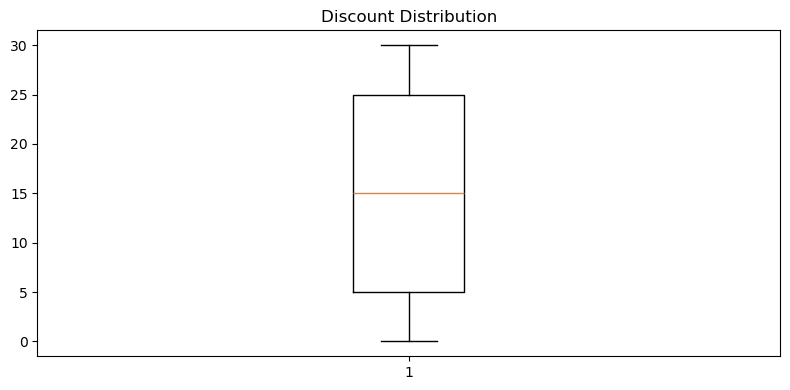

In [52]:
# Discount Boxplot (Orders)
plt.figure(figsize=(8,4))
plt.boxplot(df_orders_clean["Discount"])
plt.title("Discount Distribution")
plt.tight_layout()
plt.show()

### Outlier Investigation

Discount values above 100% were identified as business rule violations during the cleaning phase and corrected. The boxplot confirms that discount values now fall within a valid business range.

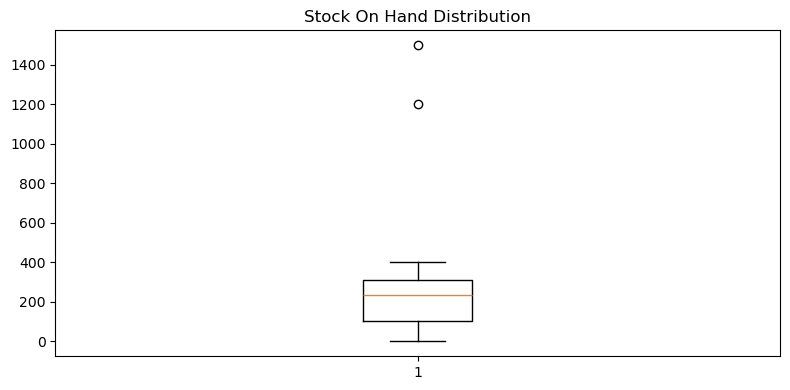

In [53]:
# Stock On Hand Boxplot (Products)
plt.figure(figsize=(8,4))
plt.boxplot(df_products_clean["Stock_On_Hand"])
plt.title("Stock On Hand Distribution")
plt.tight_layout()
plt.show()

### Outlier Investigation

Two products were identified as inventory outliers based on the boxplot.
After reviewing the records, both products belonged to valid product categories and contained realistic inventory values. No evidence of data entry errors or business rule violations was found.
Therefore, the records were retained for further analysis.

## Exploratory Data Analysis (EDA)

The objective of this section is to explore sales performance, customer behavior, product performance, return trends, and delivery operations using cleaned datasets.

This project explores key business questions such as :

- Which product categories generate the highest revenue?
- Which customer segments contribute the most sales?
- Which locations drive the strongest business performance?
- How do customer purchasing behaviors differ across membership types and payment methods?
- Which products and suppliers contribute most to revenue and returns?
- Are there inventory or delivery performance risks that require attention?

### Q1 : Which Category Generates the Highest Revenue? 

--- Show Revenue Share (%) --- 
         Category  Revenue_%
6     Living Room       13.8
5        Lighting       12.9
3  Kids Furniture       11.4
8         Outdoor       11.1
9         Storage       11.0


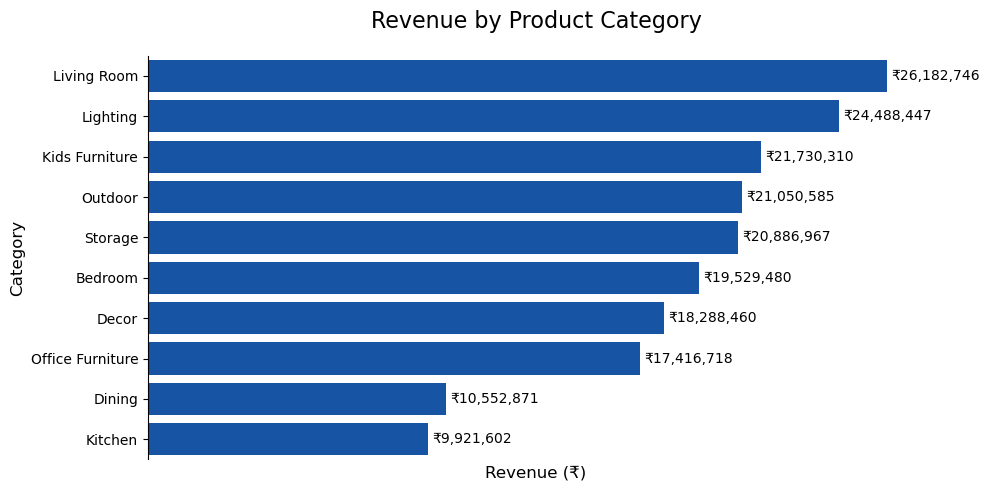

In [54]:
# Merge orders & products
category_sales = pd.merge(df_orders_clean, df_products_clean[["Product_ID", "Category"]], how="left", on="Product_ID")

# Calculate Ravenue by Category
revenue_by_category = category_sales.groupby("Category")["Sales_Amount"].sum().reset_index().sort_values(by="Sales_Amount", ascending=False)

# Calculate Revenue Share %
revenue_by_category["Revenue_%"] = (revenue_by_category["Sales_Amount"] / revenue_by_category["Sales_Amount"].sum()) * 100
print("--- Show Revenue Share (%) --- ")
print(revenue_by_category[["Category", "Revenue_%"]].round(1).head())

# Horizontal Bar Plot
plt.figure(figsize=(10,5), dpi=100)

ax = sns.barplot(x = "Sales_Amount", y = "Category", data = revenue_by_category, color="#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt="₹{:,.0f}", padding=3)

ax.set_title("Revenue by Product Category", fontsize=16, pad=20)
ax.set_xlabel("Revenue (₹)", fontsize=12)
ax.set_ylabel("Category", fontsize=12)
ax.set_xticks([])

sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()

### Key Insights
- Living Room generated the highest revenue at ₹26.18M.
- Living Room contributes 13.8% of total revenue.
- Lighting and Kids Furniture were the second and third highest revenue-generating categories.
- Kitchen generated the lowest revenue among all categories.
- Revenue is relatively well distributed across categories, indicating a diversified product portfolio instead of dependency on only one category.

### Q2 : Which City Contributes the Most Sales?

--- Revenue Share (%) ---
        City  Revenue_%
5     Jaipur       13.0
1  Bangalore       12.5
2    Chennai       10.8
4  Hyderabad       10.5
3      Delhi       10.5

Top 5 Cities Revenue Share : 57.1%



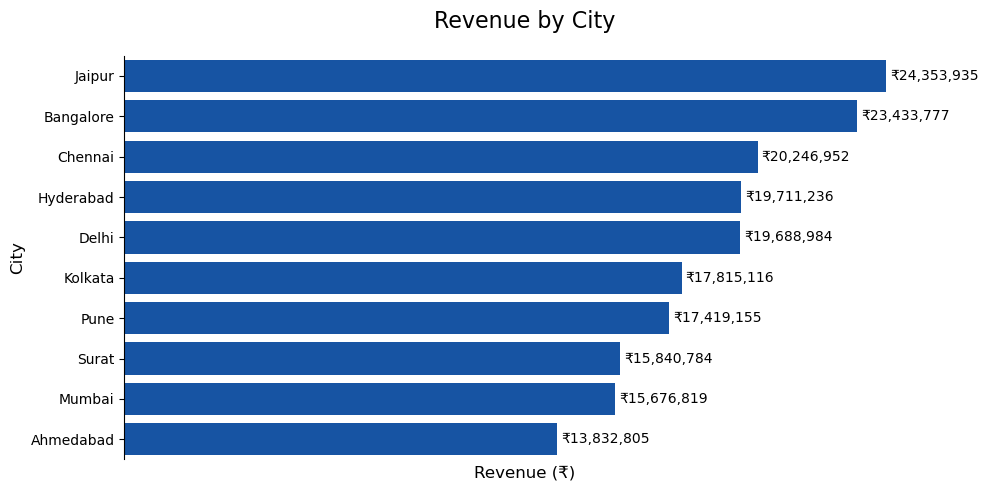

In [55]:
# Merge orders & customers
city_revenue = pd.merge(df_orders_clean, df_customers_clean[["Customer_ID", "City"]], how="left", on="Customer_ID")

# Exclude Unknown City

city_revenue = city_revenue[city_revenue["City"] != "Unknown"]

# Calculate Revenue by City
revenue_by_city = city_revenue.groupby("City")["Sales_Amount"].sum().reset_index().sort_values(by="Sales_Amount", ascending=False)

# Calculate Revenue Share %
revenue_by_city["Revenue_%"] = (revenue_by_city["Sales_Amount"] / revenue_by_city["Sales_Amount"].sum()) * 100 
print("--- Revenue Share (%) ---")
print(revenue_by_city[["City", "Revenue_%"]].round(1).head())

top_5_share = revenue_by_city.head()["Revenue_%"].sum()
print(f"\nTop 5 Cities Revenue Share : {top_5_share:.1f}%\n")

# Horizontal Bar Plot
plt.figure(figsize=(10,5), dpi=100)

ax = sns.barplot(x = "Sales_Amount", y = "City", data = revenue_by_city, color="#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt="₹{:,.0f}", padding=3)

ax.set_title("Revenue by City", fontsize=16, pad=20)
ax.set_xlabel("Revenue (₹)", fontsize=12)
ax.set_ylabel("City", fontsize=12)
ax.set_xticks([])

sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()

### Key Insights
- Jaipur generated the highest revenue at ₹24.35M.
- Jaipur contributed 13% of total revenue, making it the highest revenue-generating city.
- Bangalore closely followed Jaipur, contributing 12.5% of total revenue.
- The top five cities accounted for 57.1% of total revenue, indicating that sales are concentrated in a few key urban markets.
- The top five cities collectively contributed more than half of total revenue.
- Revenue is concentrated in major metropolitan markets, highlighting strong urban demand for IKEA products.

### Q3 : Which Membership Type Spends the Most?

--- Revenue Share (%) ---
  Membership_Type  Revenue_%
0        Business       27.6
3         Regular       26.0
1          Family       23.8
2         Premium       22.5


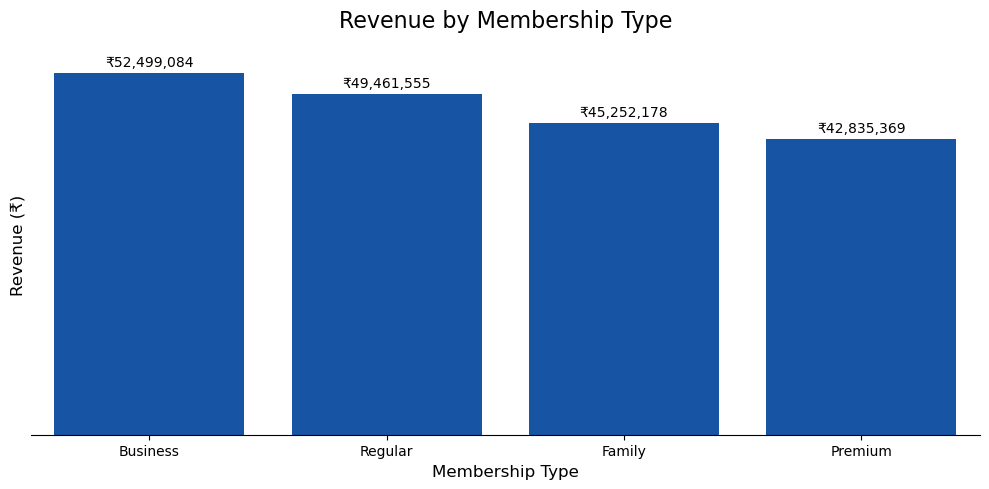

In [56]:
# Merge orders & customers
membership_revenue = pd.merge(df_orders_clean, df_customers_clean[["Customer_ID", "Membership_Type"]], how="left", on="Customer_ID")

# Calculating Revenue by Membership Type
revenue_by_membership = membership_revenue.groupby("Membership_Type")["Sales_Amount"].sum().reset_index().sort_values(by="Sales_Amount", ascending=False)

# Calculating Revenue Share %
revenue_by_membership["Revenue_%"] = (revenue_by_membership["Sales_Amount"] / revenue_by_membership["Sales_Amount"].sum()) * 100
print("--- Revenue Share (%) ---")
print(revenue_by_membership[["Membership_Type", "Revenue_%"]].round(1))

# Vertical Bar Chart
plt.figure(figsize=(10,5), dpi=100)

ax = sns.barplot(x = "Membership_Type", y = "Sales_Amount", data = revenue_by_membership, color = "#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt="₹{:,.0f}", padding = 3)

ax.set_title("Revenue by Membership Type", fontsize = 16, pad = 20)
ax.set_xlabel("Membership Type", fontsize = 12)
ax.set_ylabel("Revenue (₹)", fontsize = 12)
ax.set_yticks([])

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Key Insights
- Business members generated the highest revenue at ₹52.5M.
- Business members contributed 27.6% of total revenue, making them the most valuable customer segment.
- Regular members closely followed with 26.0% of total revenue.
- Premium members generated the lowest revenue share at 22.5%.
- Revenue is relatively balanced across membership types, indicating that sales are not heavily dependent on a single customer segment.

### Q4 : Which Age Group Spends the Most?

--- Revenue Sahre (%) ---
  Age_Group  Revenue_%
4       56+       23.3
1     26-35       21.5
3     46-55       19.8
2     36-45       19.4
0     18-25       16.0

Top 3 Age Group Revenue Share : 64.6%



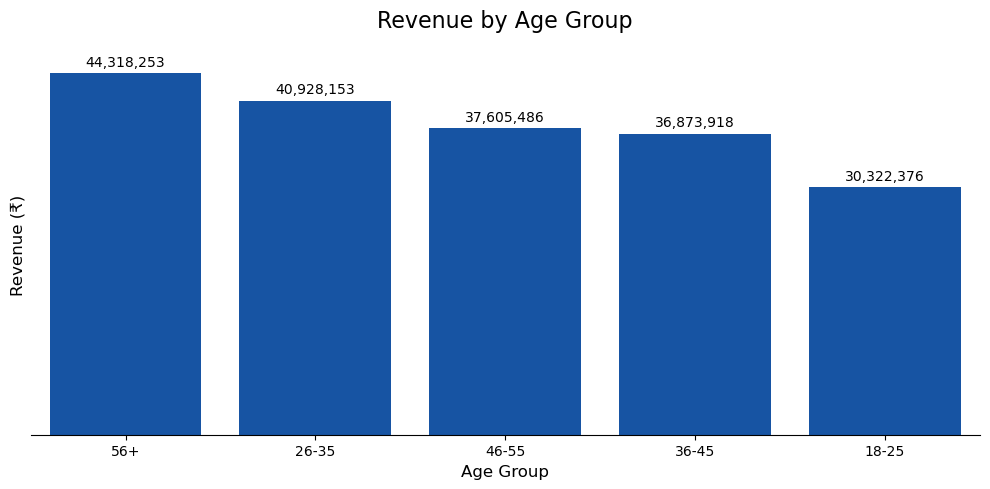

In [57]:
# Merge orders & customers
age_group_spend = pd.merge(df_orders_clean, df_customers_clean[["Customer_ID", "Age_Group"]], how="left", on="Customer_ID")

# Calculating Revenue by Age Group
spend_by_age_group = age_group_spend.groupby("Age_Group")["Sales_Amount"].sum().reset_index().sort_values(by="Sales_Amount", ascending=False)

# Calculating Revenue Share %
spend_by_age_group["Revenue_%"] = (spend_by_age_group["Sales_Amount"] / spend_by_age_group["Sales_Amount"].sum()) * 100
print("--- Revenue Sahre (%) ---")
print(spend_by_age_group[["Age_Group", "Revenue_%"]].round(1).head())

top_3_age_group_share = spend_by_age_group.head(3)["Revenue_%"].sum()
print(f"\nTop 3 Age Group Revenue Share : {top_3_age_group_share:.1f}%\n")

# Vertical Bar Plot
plt.figure(figsize=(10,5), dpi=100)

ax = sns.barplot(x = "Age_Group", y = "Sales_Amount", data = spend_by_age_group, color = "#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt = "{:,.0f}", padding = 3)

ax.set_title("Revenue by Age Group", fontsize = 16, pad = 20)
ax.set_xlabel("Age Group", fontsize = 12)
ax.set_ylabel("Revenue (₹)", fontsize = 12)
ax.set_yticks([])

sns.despine(left = True, bottom = False)
plt.tight_layout()
plt.show()

### Key Insights
- The 56+ age group generated the highest revenue at ₹44.3M.
- Customers aged 56+ contributed 23.3% of total revenue.
- The 26–35 age group was the second-highest revenue contributor with 21.5% of total revenue.
- The top three age groups accounted for 64.6% of total revenue.
- Revenue is concentrated among older and middle-aged customers, suggesting stronger purchasing power within these demographics.

### Q5 : Which Payment Method Is Most Used?

--- Share (%) ---
Payment_Method
Net Banking         21.4
Cash on Delivery    20.0
Credit Card         19.8
UPI                 19.7
Debit Card          19.0
Name: proportion, dtype: float64


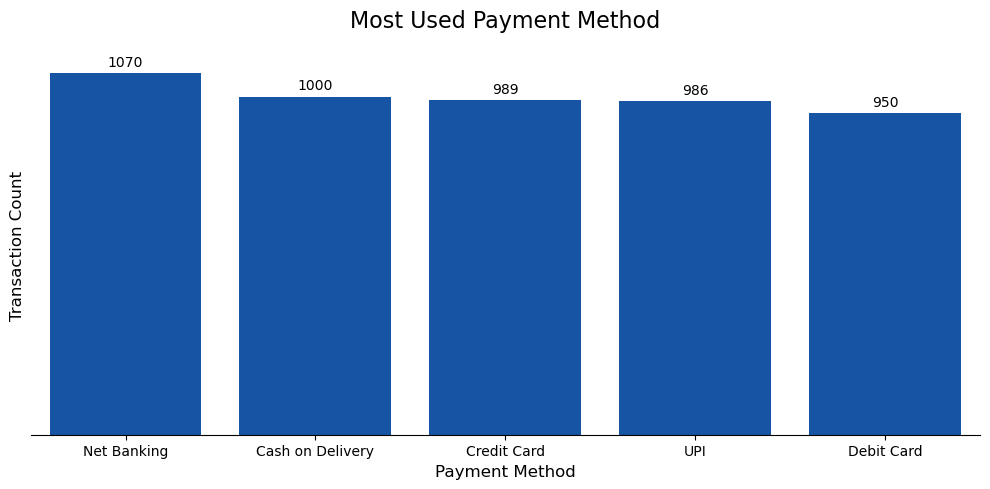

In [58]:
# Filter Payment 
payment_filter = df_orders_clean[df_orders_clean["Payment_Method"] != "Not Specified"]

# Sort Highest to Lowest
payment_order = payment_filter["Payment_Method"].value_counts().index

# Calculating Share %
payment_share = payment_filter["Payment_Method"].value_counts(normalize = True).mul(100).round(1)
print("--- Share (%) ---")
print(payment_share)

# Count Plot
plt.figure(figsize = (10,5), dpi = 100)

ax = sns.countplot(x = "Payment_Method", data = payment_filter, color = "#0051BA", order = payment_order)

for bars in ax.containers:
    ax.bar_label(bars, padding = 3)

ax.set_title("Most Used Payment Method", fontsize = 16, pad = 20)
ax.set_xlabel("Payment Method", fontsize = 12)
ax.set_ylabel("Transaction Count", fontsize = 12)
ax.set_yticks([])

sns.despine(left = True, bottom = False)
plt.tight_layout()
plt.show()

### Key Insights
- Net Banking was the most frequently used payment method with 1,070 transactions.
- Net Banking accounted for 21.4% of all transactions.
- Cash on Delivery was the second most used payment method with 1,000 transactions.
- Payment usage was relatively balanced across methods, with no single payment option dominating customer behavior.
- Customers showed strong adoption of digital payment methods such as Net Banking, Credit Card, and UPI.

### Q6: Which Products Have the Highest Return Rate?

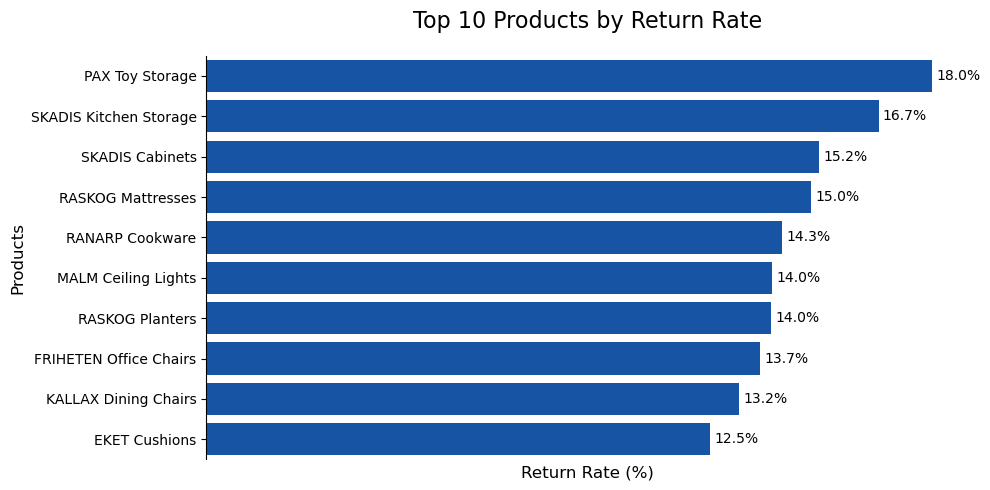

In [59]:
# Merge orders & products
product_order = pd.merge(df_orders_clean, df_products_clean[["Product_ID", "Product_Name"]], how = "left", on = "Product_ID")

# Calculating total order per product
product_order_count = product_order.groupby("Product_Name").size().reset_index(name = "Total_Orders")

# Calculating returned order per product
returned_orders = pd.merge(df_returns_clean, df_orders_clean[["Order_ID", "Product_ID"]], how = "left", on = "Order_ID")

returned_orders = pd.merge(returned_orders, df_products_clean[["Product_ID", "Product_Name"]], how = "left", on = "Product_ID")

product_returns_count = returned_orders.groupby("Product_Name").size().reset_index(name = "Returned_Orders")

# Calculating Return Rate %
return_rate = pd.merge(product_order_count, product_returns_count, how = "left", on = "Product_Name")

return_rate["Returned_Orders"] = return_rate["Returned_Orders"].fillna(0)

return_rate["Return_Rate_%"] = (return_rate["Returned_Orders"] / return_rate["Total_Orders"]) * 100

top_returns = return_rate.sort_values("Return_Rate_%",ascending=False).head(10)

# Horizontal Bar Plot
plt.figure(figsize = (10,5), dpi = 100)

ax = sns.barplot(x = "Return_Rate_%", y = "Product_Name", data = top_returns, color = "#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt = "%.1f%%", padding = 3)
    
ax.set_title("Top 10 Products by Return Rate", fontsize = 16, pad = 20)
ax.set_xlabel("Return Rate (%)", fontsize = 12)
ax.set_ylabel("Products", fontsize = 12)
ax.set_xticks([])

sns.despine(left = False, bottom = True)
plt.tight_layout()
plt.show()

### Key Insights
- PAX Toy Storage recorded the highest return rate at 18.0%.
- Storage and furniture products accounted for the majority of the highest-returned items, suggesting potential opportunities to review product quality, assembly experience, or customer expectations.
- The top-returned products may indicate customer dissatisfaction, product quality issues, or unmet expectations.
- Return rates varied considerably across products, suggesting opportunities for targeted product-level investigation.
- Products with consistently high return rates should be reviewed to identify potential operational or product-related issues.

### Q7 : Which Suppliers Generate the Highest Revenue?

--- Revenue Share (%) ---
           Supplier  Revenue_%
2    Supplier Local       20.4
4    Supplier South       20.1
3    Supplier North       17.3
0  Supplier Central       15.2
1     Supplier East       14.4
5     Supplier West       12.6

Top 3 Supplier Revenue Share: 57.8%


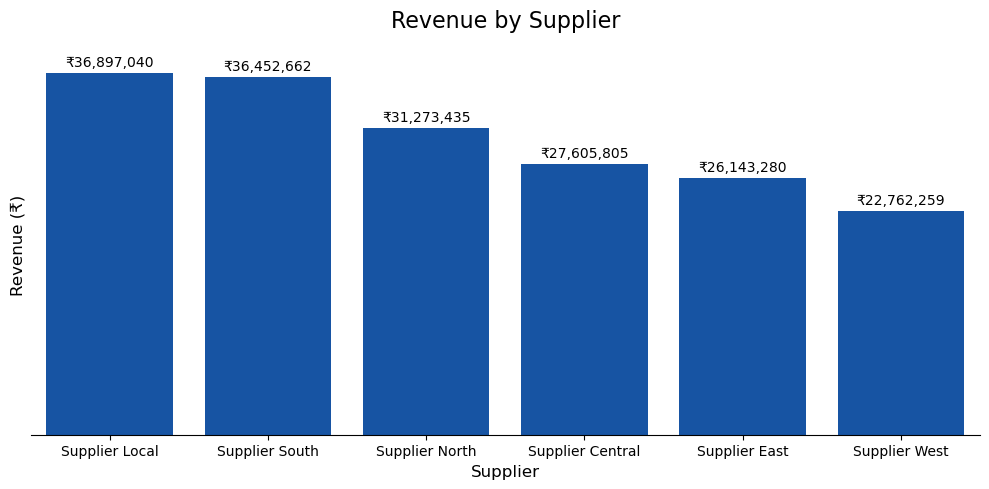

In [60]:
# Merge orders & products
supplier_revenue = pd.merge(df_orders_clean, df_products_clean[["Product_ID", "Supplier"]], how = "left", on = "Product_ID")

# Exclude Unknown Suppliers
supplier_revenue = supplier_revenue[supplier_revenue["Supplier"] != "Unknown"]

# Calculating Revenue by Supliers
revenue_by_supplier = supplier_revenue.groupby("Supplier")["Sales_Amount"].sum().reset_index().sort_values(by="Sales_Amount", ascending=False)

# Calculating Revenue Share % 
revenue_by_supplier["Revenue_%"] = (revenue_by_supplier["Sales_Amount"] / revenue_by_supplier["Sales_Amount"].sum()) * 100
print("--- Revenue Share (%) ---")
print(revenue_by_supplier[["Supplier", "Revenue_%"]].round(1))

# Top 3 Suppliers Share %
top_3_supplier_share = revenue_by_supplier.head(3)["Revenue_%"].sum()

print(f"\nTop 3 Supplier Revenue Share: {top_3_supplier_share:.1f}%")

# Vertical Bar Plot
plt.figure(figsize = (10,5), dpi = 100)

ax = sns.barplot(x = "Supplier", y = "Sales_Amount", data = revenue_by_supplier, color = "#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt = "₹{:,.0f}", padding = 3)

ax.set_title("Revenue by Supplier", fontsize = 16, pad = 20)
ax.set_xlabel("Supplier", fontsize = 12)
ax.set_ylabel("Revenue (₹)", fontsize = 12)
ax.set_yticks([])

sns.despine(left = True, bottom = False)
plt.tight_layout()
plt.show()

### Key Insights
- Supplier Local generated the highest revenue at ₹36.9M.
- Supplier Local contributed 20.4% of total revenue.
- Supplier South closely followed with 20.1% of total revenue.
- The top three suppliers accounted for 57.8% of total revenue.
- Revenue is moderately concentrated among a few suppliers, highlighting the importance of maintaining strong supplier relationships and managing supplier dependency risk.

### Q8 : Which Categories Have Inventory Risk?

**Inventory Risk Score Formula**

Risk Score = Total Demand ÷ Average Stock

Higher values indicate greater potential stockout risk.

In [ ]:
# Average Stock by Category
inventory_risk = df_products_clean.groupby("Category")["Stock_On_Hand"].mean().reset_index()

# Rename to Avg Stock
inventory_risk.rename(columns = {"Stock_On_Hand" : "Avg_Stock"}, inplace = True)

# Calculating Demand by Category
category_demand = pd.merge(df_orders_clean, df_products_clean[["Product_ID", "Category"]], how = "left", on = "Product_ID")

category_demand = category_demand.groupby("Category")["Quantity"].sum().reset_index()

# Rename to Total Demand
category_demand.rename(columns = {"Quantity" : "Total_Demand"}, inplace = True)

# Combine Both 
inventory_risk = pd.merge(inventory_risk, category_demand, how = "left", on = "Category")

# Calculating Risk Score
inventory_risk["Risk_Score"] = inventory_risk["Total_Demand"] / inventory_risk["Avg_Stock"]

# Sorting High Risk First
inventory_risk = inventory_risk.sort_values("Risk_Score", ascending = False)
print(inventory_risk.head(2))

# Horizontal Bar Plot
plt.figure(figsize = (10,5), dpi = 100)

ax = sns.barplot(x = "Risk_Score", y = "Category", data = inventory_risk, color = "#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f", padding = 3)

ax.set_title("Inventory Risk by Category", fontsize = 16, pad = 20)
ax.set_xlabel("Risk Score", fontsize = 12)
ax.set_ylabel("Category", fontsize = 12)
ax.set_xticks([])

sns.despine(left = False, bottom = True)
plt.tight_layout()
plt.show()

### Key Insights
- Kids Furniture recorded the highest inventory risk score at 6.3, indicating the greatest potential stockout risk among all categories.
- Lighting and Storage categories also showed elevated inventory risk levels.
- High demand combined with relatively lower inventory levels increases the likelihood of stock shortages.
- Dining exhibited the lowest inventory risk score, indicating healthier inventory coverage relative to demand.
- Inventory risk varies considerably across categories, highlighting opportunities to improve inventory planning and replenishment strategies.

### Q9: Do Delayed Deliveries Relate to Returns?

  Delivery_Status  Returned  Return_Rate_%
0         Delayed  0.074074       7.407407
1       Delivered  0.081100       8.110031


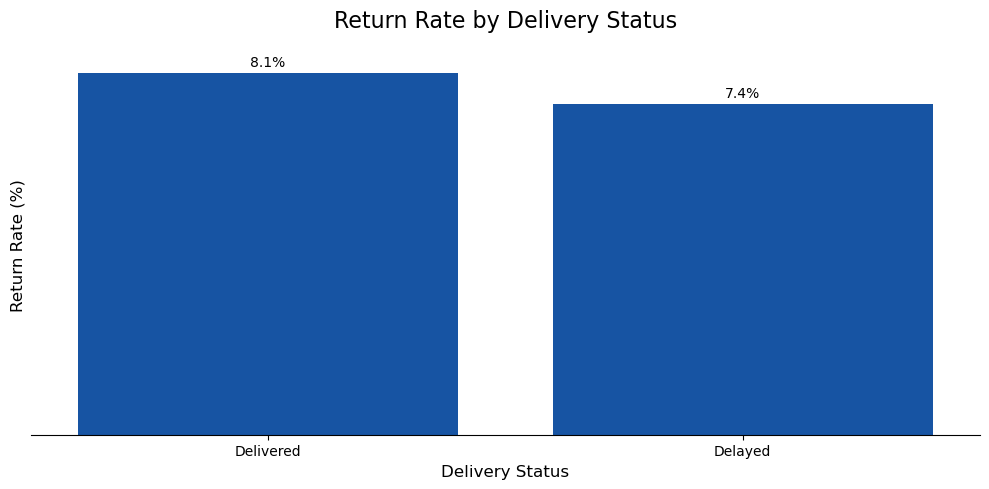

In [62]:
# Merge deliveries & returns
delivery_return = pd.merge(df_deliveries_clean, df_returns_clean[["Order_ID", "Return_ID"]], how = "left", on = "Order_ID")

# Return Flag
delivery_return["Returned"] = delivery_return["Return_ID"].notnull()

# Return Rate by Delivery Status
return_rate_delivery = delivery_return.groupby("Delivery_Status")["Returned"].mean().reset_index()

return_rate_delivery["Return_Rate_%"] = return_rate_delivery["Returned"] * 100
print(return_rate_delivery)

# Short Highest Return Rate First
return_rate_delivery = return_rate_delivery.sort_values(by = "Return_Rate_%", ascending = False)

# Bar Plot
plt.figure(figsize = (10,5), dpi = 100)

ax = sns.barplot(x = "Delivery_Status", y = "Return_Rate_%", data = return_rate_delivery, color = "#0051BA")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding = 3)

ax.set_title("Return Rate by Delivery Status", fontsize = 16, pad = 20)
ax.set_xlabel("Delivery Status", fontsize = 12)
ax.set_ylabel("Return Rate (%)", fontsize = 12)
ax.set_yticks([])

sns.despine(left = True, bottom = False)
plt.tight_layout()
plt.show()

### Key Insights
- Delivered orders recorded a return rate of 8.1%, slightly higher than delayed orders at 7.4%.
- Delayed deliveries did not exhibit a higher return rate in this dataset.
- The difference between delivered and delayed return rates was relatively small (0.7 percentage points).
- Delivery performance does not appear to be a major factor influencing product returns.
- Product-related issues, customer preferences, or return reasons may have a stronger impact on return behavior than delivery delays.

### Q10 : What Customer/Product Factors Appear Linked With Returns?

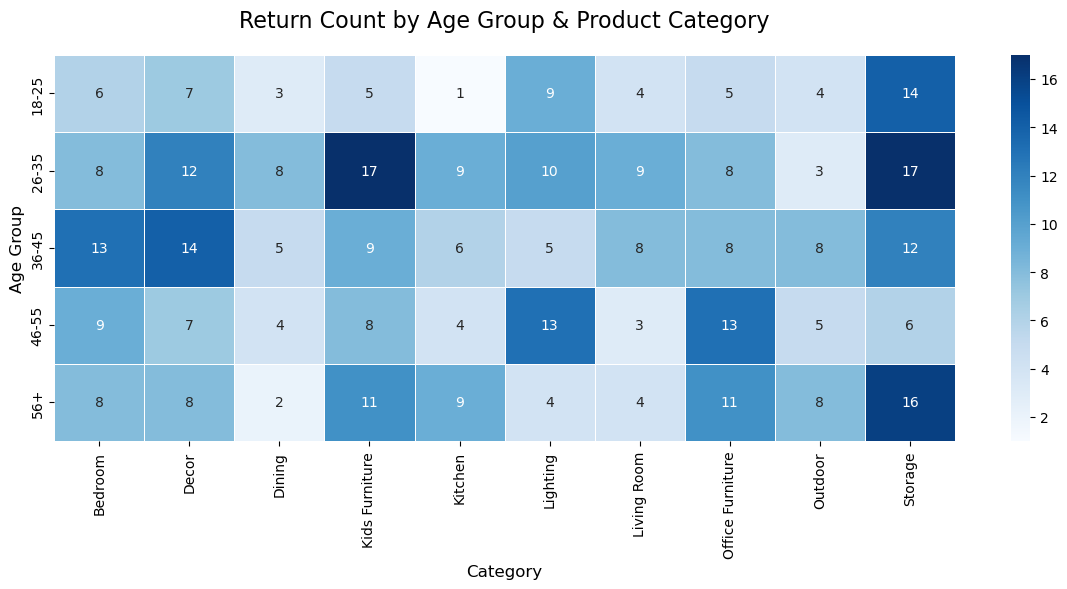

In [63]:
# Merge returns & orders
return_analysis = pd.merge(df_returns_clean, df_orders_clean, how = "left", on = "Order_ID")

# Merge customers
return_analysis = pd.merge(return_analysis, df_customers_clean[["Customer_ID", "Age_Group"]], how = "left", on = "Customer_ID")

# Merge products
return_analysis = pd.merge(return_analysis, df_products_clean[["Product_ID", "Category"]], how = "left", on = "Product_ID")

# Heatmap 
heatmap_data = pd.pivot_table(return_analysis, index = "Age_Group", columns = "Category", values = "Return_ID", aggfunc = "count", fill_value = 0)

plt.figure(figsize=(12,6))

sns.heatmap(heatmap_data, annot = True, fmt = ".0f", cmap = "Blues", linewidths = 0.5)

plt.title("Return Count by Age Group & Product Category", fontsize = 16, pad = 20)

plt.xlabel("Category", fontsize = 12)
plt.ylabel("Age Group", fontsize = 12)

plt.tight_layout()
plt.show()

### Key Insights
- Returns were not evenly distributed across customer segments and product categories.
- Customers aged 26–35 generated the highest return counts for Kids Furniture and Storage products.
- Storage products recorded consistently high return activity across multiple age groups.
- Older customers (56+) also exhibited elevated return counts for Storage and Office Furniture products.
- The heatmap suggests that product category may have a stronger influence on return behavior than age group alone.

## EDA Summary & Key Findings

### Overall Conclusion
The analysis revealed that revenue is driven primarily by Living Room products, Business members, and customers aged 56+. Inventory risk is concentrated in high-demand categories such as Kids Furniture and Storage, while return behavior appears to be influenced more by product categories and customer segments than by delivery delays. These findings can support inventory planning, supplier management, customer targeting, and product quality improvement initiatives.

### Key Findings
- Living Room generated the highest revenue, contributing approximately 13.8% of total sales, while Kitchen generated the lowest revenue.
- Jaipur and Bangalore were the top revenue-generating cities, together contributing nearly 25% of total sales.
- Business membership customers contributed the highest revenue share, indicating stronger spending behavior than other membership segments.
- Customers aged 56+ generated the highest revenue, followed closely by the 26–35 age group, suggesting stronger purchasing power among older and middle-aged customers.
- Net Banking was the most frequently used payment method, though payment usage remained relatively balanced across all methods.
- PAX Toy Storage recorded the highest return rate (18.0%), highlighting potential product-level issues or unmet customer expectations.
- Supplier Local and Supplier South were the highest revenue-contributing suppliers, and the top three suppliers accounted for 57.8% of total revenue.
- Kids Furniture, Lighting, and Storage categories exhibited the highest inventory risk scores, indicating potential stockout risk due to high demand relative to available inventory.
- Delivery delays did not significantly increase return rates, suggesting that product-related factors may have a stronger influence on customer returns than delivery performance.
- Return activity was concentrated in specific age group and product category combinations, with Storage and Kids Furniture showing consistently high return volumes across multiple customer segments.

### Business Recommendation
Based on the analysis, IKEA should prioritize inventory planning for Kids Furniture and Storage categories, monitor high-return products such as PAX Toy Storage, and maintain strong relationships with key suppliers contributing the majority of revenue. Return behavior appears to be influenced more by product and customer segment characteristics than by delivery delays.

In [69]:
# Export Clean CSV Files
df_customers_clean.to_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\cleaned\customers_cleaned.csv", index = False)
df_orders_clean.to_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\cleaned\orders_cleaned.csv", index = False)
df_products_clean.to_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\cleaned\products_cleaned.csv", index = False)
df_deliveries_clean.to_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\cleaned\deliveries_cleaned.csv", index = False)
df_returns_clean.to_csv(r"D:\Data Analytics\Projects\IKEA_Sales_Operation_Analysis\Data\cleaned\returns_cleaned.csv", index = False)

print("All cleaned datasets exported successfully.")

All cleaned datasets exported successfully.
